# RFM-анализ клиентов интернет-магазина

**Цель проекта:** сегментировать клиентов онлайн-ритейлера по трём признакам — давности,
частоте и сумме покупок (Recency, Frequency, Monetary) — чтобы выделить группы клиентов
для разных маркетинговых стратегий (удержание, реактивация, VIP-программы и т.д.).

**Датасет:** [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI ML Repository) —
транзакции UK-интернет-магазина подарков за период с 01.12.2009 по 09.12.2011, 1 067 371 строка.

**Стек:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, `ydata-profiling`.

**Содержание:**
1. Загрузка и обзор данных
2. Очистка данных
3. Расчёт метрик R, F, M
4. RFM-скоринг
5. Сегментация клиентов
6. Визуализация
7. Выводы и рекомендации


## 1. Загрузка и обзор данных

In [44]:
%matplotlib inline

In [45]:
# Библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Автоматический EDA-отчёт (профилирование датасета)
from ydata_profiling import ProfileReport


In [46]:
# Исходные транзакционные данные интернет-магазина (Online Retail II)
df = pd.read_csv("rfm_data.csv")


Проверяем типы данных, количество непустых значений и базовую статистику
по числовым колонкам. Уже здесь видно две проблемы:
- `Customer ID` заполнен не полностью — часть заказов оформлена без привязки к клиенту;
- `Quantity` и `Price` имеют отрицательные минимумы — это возвраты/отмены заказов.

In [47]:
# Общая информация о датасете: типы колонок, пропуски, память
df.info()

# Описательная статистика по всем колонкам (включая категориальные)
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [48]:
# Первые 5 строк — визуально знакомимся со структурой данных
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Автоматический профайлинг данных

`ydata_profiling` строит подробный интерактивный отчёт (распределения, корреляции, дубликаты
и т.д.). Отчёт полезен на этапе разведочного анализа, но его HTML-вывод весит несколько
мегабайт, поэтому в репозитории он не сохраняется — при необходимости просто выполните ячейку
локально.

In [49]:
# Интерактивный EDA-отчёт
profile = ProfileReport(df)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:01<00:00,  4.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 2. Очистка данных

In [51]:
# Считаем пропуски по каждой колонке
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

`Customer ID` не заполнен примерно в 23% строк (243 007 из 1 067 371) — это разовые
заказы без регистрации. Без ID клиента такие строки нельзя привязать ни к одному клиенту,
поэтому они будут удалены на следующем шаге.

In [52]:
# Ищем полные дубликаты строк (одинаковые во всех колонках)
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


Явные дубликаты — вероятно, повторно выгруженные строки из системы учёта.
Для RFM-метрик они не критичны (Frequency считается по уникальным `Invoice`, а не по строкам),
но для чистоты данных отфильтруем отрицательные `Quantity` и `Price`:
- отрицательное `Quantity` — возврат товара (Invoice с префиксом `C`);
- отрицательная/нулевая `Price` — технические строки (списания, корректировки), не реальные продажи.

In [53]:
# Оставляем только реальные продажи: положительное количество и положительную цену
df.query("Quantity>0", inplace=True)
df.query("Price>0", inplace=True)

In [54]:
df.isna().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236122
Country             0
dtype: int64

In [55]:
# Убираем заказы без привязки к клиенту — RFM считается только по идентифицируемым клиентам
df.dropna(subset=["Customer ID"], inplace=True)

In [56]:
# Итоговый размер очищенного датасета
df.shape

(805549, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  object 
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB


In [60]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [59]:
# Датасет готов к расчёту RFM-метрик
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Расчёт метрик R, F, M

In [61]:
# Оставляем только дату (без времени) — для Recency точность до дня достаточна
df["InvoiceDate"] = pd.to_datetime(df.InvoiceDate).dt.date

In [62]:
# "Точка отсчёта" для Recency — дата последней транзакции в датасете
today_date = df["InvoiceDate"].max()
print(today_date)

2011-12-09


### 3.1 Recency — сколько дней прошло с последней покупки клиента

In [63]:
# Для каждого клиента находим дату его последней покупки
R_score = df.groupby("Customer ID", as_index=False).agg({"InvoiceDate": "max"})


In [64]:
R_score.head()

,Customer ID,InvoiceDate
0,12346.0,2011-01-18
1,12347.0,2011-12-07
2,12348.0,2011-09-25
3,12349.0,2011-11-21
4,12350.0,2011-02-02


In [65]:
# Recency = сколько дней прошло между последней покупкой клиента и датой отсчёта
R_score['Recency'] = (today_date - R_score["InvoiceDate"])


In [66]:
R_score.Recency = R_score.Recency.apply(lambda x: x.days)

In [67]:
R_score = R_score[["Customer ID", "Recency"]]

### 3.2 Frequency — сколько уникальных заказов сделал клиент

In [68]:
# Считаем количество уникальных Invoice на клиента (не строк, а именно заказов —
# в одном заказе может быть много позиций)
F_score = df.groupby("Customer ID", as_index=False).agg({"Invoice": "nunique"})
F_score = F_score.rename(columns={"Invoice": "Frequency"})
F_score.head()

,Customer ID,Frequency
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


### 3.3 Monetary — сколько клиент потратил всего

In [69]:
# Берём только нужные для расчёта колонки
M_score = df[["Customer ID", "Price", "Quantity"]].copy()

In [70]:
M_score.head()

,Customer ID,Price,Quantity
0,13085.0,6.95,12
1,13085.0,6.75,12
2,13085.0,6.75,12
3,13085.0,2.10,48
4,13085.0,1.25,24


In [71]:
# Сумма конкретной позиции заказа = цена за единицу * количество
M_score["Monetary"] = M_score["Price"] * M_score["Quantity"]


In [72]:
# Суммируем по клиенту — получаем общую выручку с клиента за весь период
M_score = M_score.groupby("Customer ID", as_index=False).agg({"Monetary": "sum"})

## 4. Сборка RFM-таблицы и скоринг

In [73]:
# Объединяем три метрики в единую витрину по клиентам
rfm = R_score.merge(F_score, on='Customer ID').merge(M_score, on='Customer ID')
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,325,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,310,1,334.40


### RFM-скоринг

Разбиваем клиентов на 3 равные по размеру группы (терцили) по каждой метрике с помощью
`pd.qcut`. Чем выше скор — тем "лучше" клиент, поэтому направление шкал разное:

- **Recency** — чем МЕНЬШЕ дней прошло с последней покупки, тем ЛУЧШЕ клиент,
  поэтому метки идут в обратном порядке (`[3, 2, 1]`);
- **Frequency** и **Monetary** — чем БОЛЬШЕ значение, тем ЛУЧШЕ клиент,
  метки идут в прямом порядке (`[1, 2, 3]`).

In [74]:
# 3 = лучшая группа, 1 = худшая — для всех трёх метрик
rfm["R_score"] = pd.qcut(rfm["Recency"], 3, labels=[3, 2, 1])    # недавно купившие => выше скор
rfm["F_score"] = pd.qcut(rfm["Frequency"], 3, labels=[1, 2, 3])  # чаще покупающие => выше скор
rfm["M_score"] = pd.qcut(rfm["Monetary"], 3, labels=[1, 2, 3])   # больше тратящие => выше скор


In [75]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,325,12,77556.46,1,3,3
1,12347.0,2,8,5633.32,3,3,3
2,12348.0,75,5,2019.40,2,2,3
3,12349.0,18,4,4428.69,3,2,3
4,12350.0,310,1,334.40,1,1,1


In [76]:
# Комбинированный RFM-код (например, "333" — лучшие клиенты по всем трём измерениям)
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

In [77]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.0,325,12,77556.46,1,3,3,133
1,12347.0,2,8,5633.32,3,3,3,333
2,12348.0,75,5,2019.40,2,2,3,223
3,12349.0,18,4,4428.69,3,2,3,323
4,12350.0,310,1,334.40,1,1,1,111


## 5. Сегментация клиентов

Сырой `RFM_score` (27 возможных комбинаций при 3 уровнях на каждую метрику) неудобно
интерпретировать бизнесу напрямую, поэтому агрегируем комбинации в понятные именованные
сегменты по правилам:

| Сегмент | Логика | Что делать |
|---|---|---|
| Чемпионы | R=3, F=3, M=3 | Программа лояльности, ранний доступ к новинкам |
| Лояльные клиенты | R≥2, F=3 | Апсейл/кросс-сейл, персональные предложения |
| Перспективные | R=3, F<3 | Стимулировать повторную покупку, welcome-серии |
| Новые клиенты | R=3, F=1, M=1 | Онбординг, знакомство с ассортиментом |
| Клиенты под угрозой оттока | R=1, F≥2 | Реактивационные кампании, спецпредложения |
| Спящие / потерянные | R=1, F=1 | Низкий приоритет, дешёвые каналы реактивации или win-back |
| Остальные | всё, что не попало выше | Стандартные коммуникации |


In [78]:
def assign_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])

    if r == 3 and f == 3 and m == 3:
        return "Champions"
    if r >= 2 and f == 3:
        return "Loyal customers"
    if r == 3 and f == 1 and m == 1:
        return "New customers"
    if r == 3 and f < 3:
        return "Potential loyalists"
    if r == 1 and f >= 2:
        return "At risk"
    if r == 1 and f == 1:
        return "Hibernating / lost"
    return "Others"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

In [79]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,12346.0,325,12,77556.46,1,3,3,133,At risk
1,12347.0,2,8,5633.32,3,3,3,333,Champions
2,12348.0,75,5,2019.40,2,2,3,223,Others
3,12349.0,18,4,4428.69,3,2,3,323,Potential loyalists
4,12350.0,310,1,334.40,1,1,1,111,Hibernating / lost


In [80]:
# Считаем клиентов и выручку по сегментам
segment_summary = (
    rfm.groupby("Segment", as_index=False)
       .agg(customers=("Customer ID", "nunique"), total_monetary=("Monetary", "sum"))
       .assign(share_customers=lambda d: (d["customers"] / d["customers"].sum() * 100).round(1),
               share_revenue=lambda d: (d["total_monetary"] / d["total_monetary"].sum() * 100).round(1))
       .sort_values("total_monetary", ascending=False)
)
segment_summary

,Segment,customers,total_monetary,share_customers,share_revenue
1,Champions,986,1.105214e+07,16.8,62.3
3,Loyal customers,689,2.527855e+06,11.7,14.2
5,Others,1374,1.342606e+06,23.4,7.6
0,At risk,521,1.171370e+06,8.9,6.6
6,Potential loyalists,642,9.580282e+05,10.9,5.4
2,Hibernating / lost,1437,6.319248e+05,24.4,3.6
4,New customers,229,5.949987e+04,3.9,0.3


## 6. Визуализация результатов

### 6.1 Распределения R, F, M

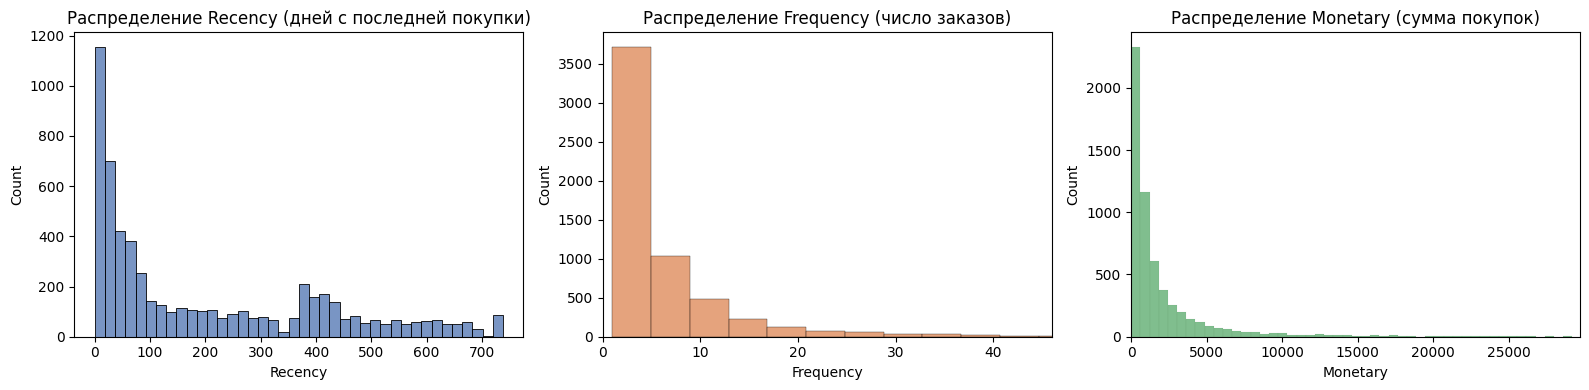

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["Recency"], bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Распределение Recency (дней с последней покупки)")

sns.histplot(rfm["Frequency"], bins=100, color="#DD8452", ax=axes[1])
axes[1].set_title("Распределение Frequency (число заказов)")
axes[1].set_xlim(0, rfm["Frequency"].quantile(0.99))  # обрезаем длинный хвост для читаемости

sns.histplot(rfm["Monetary"], bins=1000, color="#55A868", ax=axes[2])
axes[2].set_title("Распределение Monetary (сумма покупок)")
axes[2].set_xlim(0, rfm["Monetary"].quantile(0.99))

plt.tight_layout()
plt.show()


Все три метрики сильно скошены вправо: у подавляющего большинства клиентов немного
заказов на небольшую сумму, а небольшая группа клиентов — это в основном оптовые покупатели, которые генерирует
непропорционально большую выручку. 

### 6.2 Количество и выручка по сегментам

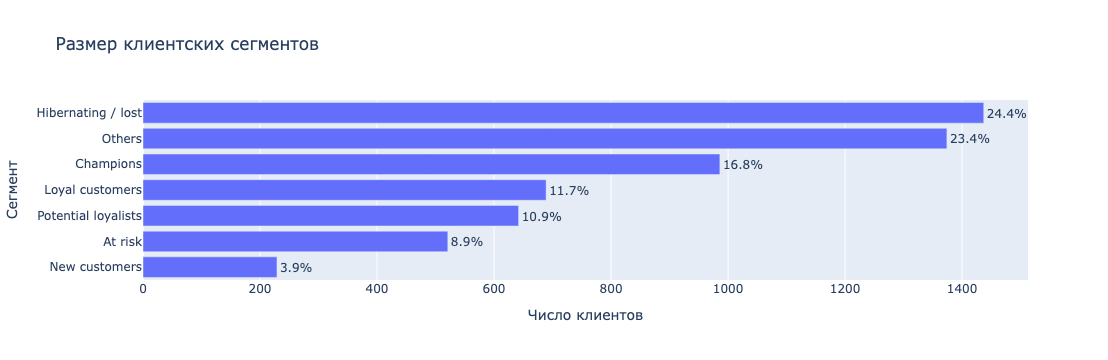

In [82]:
fig = px.bar(
    segment_summary.sort_values("customers", ascending=True),
    x="customers", y="Segment", orientation="h",
    text="share_customers",
    labels={"customers": "Число клиентов", "Segment": "Сегмент"},
    title="Размер клиентских сегментов"
)
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.show()


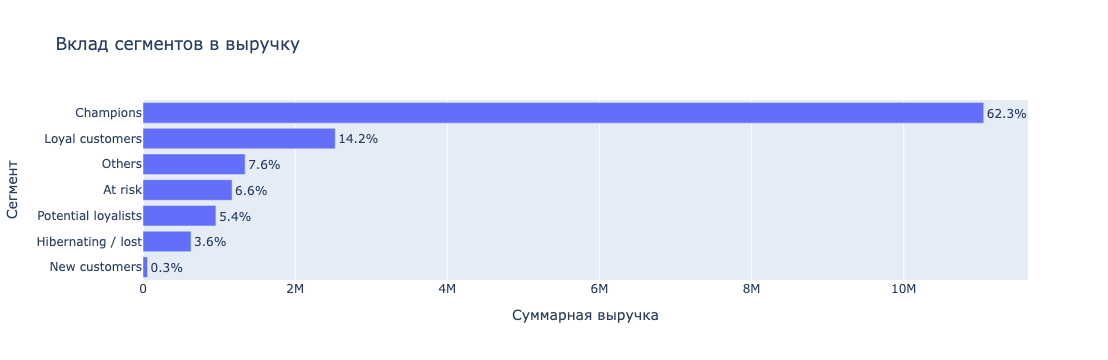

In [83]:
fig = px.bar(
    segment_summary.sort_values("total_monetary", ascending=True),
    x="total_monetary", y="Segment", orientation="h",
    text="share_revenue",
    labels={"total_monetary": "Суммарная выручка", "Segment": "Сегмент"},
    title="Вклад сегментов в выручку"
)
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.show()


Сопоставление двух графиков выше — ключевой инсайт RFM-анализа: доля сегмента в числе
клиентов и его доля в выручке обычно сильно расходятся (небольшая группа "Champions" даёт
непропорционально много выручки). Именно это расхождение оправдывает разные стратегии
коммуникации для разных сегментов, а не единый подход ко всей базе.

### 6.3 Средний чек по комбинациям Recency × Frequency

In [84]:
pivot = rfm.pivot_table(index="R_score", columns="F_score", values="Monetary", aggfunc="mean")
pivot

/var/folders/qf/x013q3jn2fzb_5zd18wyx5g40000gp/T/ipykernel_28021/3056604911.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



F_score,1,2,3
R_score,,,
3,957.051710,1336.301322,10176.958294
2,524.011940,1512.286937,4158.894368
1,439.752785,1328.583899,5131.585008


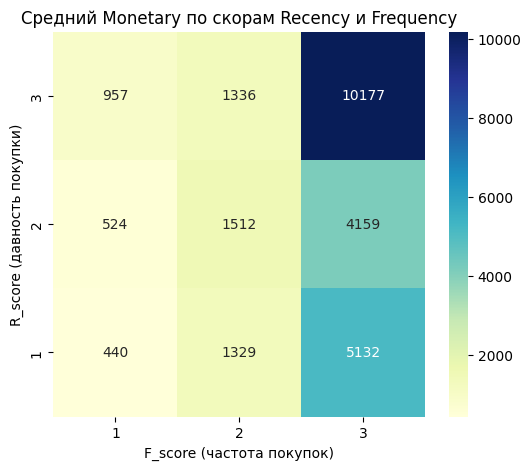

In [85]:
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Средний Monetary по скорам Recency и Frequency")
plt.xlabel("F_score (частота покупок)")
plt.ylabel("R_score (давность покупки)")
plt.show()


### 6.4 Экспорт результата

In [86]:
# Итоговый RFM DataFrame
rfm.to_csv("rfm_segments.csv", index=False)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,12346.0,325,12,77556.46,1,3,3,133,At risk
1,12347.0,2,8,5633.32,3,3,3,333,Champions
2,12348.0,75,5,2019.40,2,2,3,223,Others
3,12349.0,18,4,4428.69,3,2,3,323,Potential loyalists
4,12350.0,310,1,334.40,1,1,1,111,Hibernating / lost


## 7. Выводы и рекомендации

**Данные и очистка**
- Исходный датасет — 1 067 371 транзакционная строка за два года (Online Retail II, UCI).
- ~23% строк не имели `Customer ID` (разовые заказы без регистрации) — исключены, так как
  RFM считается на уровне клиента.
- Отрицательные `Quantity`/`Price` (возвраты и технические корректировки) отфильтрованы,
  чтобы Monetary отражал только реальные продажи.
- После очистки в анализе участвуют только идентифицируемые клиенты с валидными покупками.

**RFM-скоринг**
- Метрики Recency, Frequency и Monetary разбиты на терцили (`pd.qcut`, 3 группы), поэтому
  каждый клиент получает скор от 1 до 3 по каждой метрике и комбинированный `RFM_score` из
  27 возможных сочетаний.
- Комбинации агрегированы в 6 бизнес-сегментов (Champions, Loyal, Potential loyalists,
  New, At risk, Hibernating/lost) — с ними уже можно работать маркетингу и CRM.

**Ключевой инсайт**
- Распределения всех трёх метрик сильно скошены вправо: небольшая доля клиентов
  (в основном оптовые — по описанию датасета) обеспечивает непропорционально большую долю
  выручки. Это классическая ситуация "80/20", которая делает точечную работу с топ-сегментами
  ощутимо эффективнее, чем массовые рассылки по всей базе.

**Рекомендации по сегментам**
- **Champions / Loyal** — минимизировать риск оттока: программы лояльности, ранний доступ
  к новым позициям ассортимента, персональный менеджер для крупных оптовиков.
- **Potential loyalists / New** — стимулировать повторную покупку в первые недели
  (welcome-цепочка, промокод на второй заказ), пока клиент не "остыл".
- **At risk** — точечные реактивационные предложения: эти клиенты раньше покупали часто,
  их дешевле вернуть, чем найти новых.
- **Hibernating / lost** — низкоприоритетный сегмент: дешёвые каналы (email-рассылки) или
  явный win-back с ограниченным бюджетом, без затрат на персонализацию.
  